# Mérési notebook
---
# **2. mérési fázis**. A	Modellek tesztelése teljes tanítással.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

## 5. modell **ViT-B/16** modell teljes tanítással történő tesztelése

#### A ViT-B/16 modell teljes tanítással történő futtatása a saját SBphotothemes180k adathalmaz Test részhalmazán. (teszt elemszám: 18k).


---


✅ ViT-B/16 – Full fine-tune @ saját 114 osztály

Ez a modell egy Vision Transformer – teljesen más architektúra, mint a CNN-ek, de PyTorch alatt ugyanúgy kezelhető, főleg timm segítségével.

Ugyanazt a struktúrát követjük, mint korábban:

✅ 1. Telepítés, import, GPU ellenőrzés

In [ ]:
!pip install -q --upgrade pip
!pip install -q timm torchvision tqdm scikit-learn matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import time
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("💻 Eszköz:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 129.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 183.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 143.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 155.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 145.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 190.0 MB/s eta 0:00:00
💻 Eszköz: cuda


✅ 2. Drive csatolás + adatbázis kibontása

In [ ]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

diploma_path = "/content/drive/MyDrive/diplomamunka"
zip_path = os.path.join(diploma_path, "imagenet_splitted_db.zip")
extract_path = "/content/imagenet_splitted_db"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("✅ Adatok elérhetők:", extract_path)


Mounted at /content/drive
✅ Adatok elérhetők: /content/imagenet_splitted_db


Mappa pontosítás

In [ ]:
extract_path = "/content/imagenet_splitted_db/imagenet_splitted_db"

✅ 3. Adatok betöltése (train / val / test)

In [ ]:
batch_size = 64
num_workers = 2

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = datasets.ImageFolder(os.path.join(extract_path, "train"), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(extract_path, "val"), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(extract_path, "test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

class_names = train_dataset.classes
num_classes = len(class_names)
print(f"📚 Kategóriák száma: {num_classes}")


📚 Kategóriák száma: 114


✅ 4. Modell módosítása (ViT-B/16 → 114 osztály)

In [ ]:
import timm

model = timm.create_model("vit_base_patch16_224", pretrained=True)
model.head = nn.Linear(model.head.in_features, num_classes)
model = model.to(device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

✅ 5. Optimizer, loss, statisztikák előkészítése

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

num_epochs = 10
train_loss_hist, val_loss_hist = [], []
train_acc_hist, val_acc_hist = [], []


✅ 6. Tanítási ciklus (train + val)

In [ ]:
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - train"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    # Validáció
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - val"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= total
    val_acc = correct / total
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f"📊 Epoch {epoch+1}: Train loss={train_loss:.4f}, acc={train_acc:.4f} | Val loss={val_loss:.4f}, acc={val_acc:.4f}")


Epoch 1/10 - val: 100%|██████████| 282/282 [00:42<00:00,  6.70it/s]


📊 Epoch 1: Train loss=1.2851, acc=0.6443 | Val loss=1.1000, acc=0.6794


Epoch 2/10 - val: 100%|██████████| 282/282 [00:42<00:00,  6.69it/s]


📊 Epoch 2: Train loss=0.8488, acc=0.7472 | Val loss=0.9895, acc=0.7195


Epoch 3/10 - val: 100%|██████████| 282/282 [00:42<00:00,  6.68it/s]


...

📊 Epoch 8: Train loss=0.2482, acc=0.9230 | Val loss=1.1802, acc=0.7378


Epoch 9/10 - val: 100%|██████████| 282/282 [00:42<00:00,  6.67it/s]


📊 Epoch 9: Train loss=0.2237, acc=0.9297 | Val loss=1.2074, acc=0.7470


Epoch 10/10 - val: 100%|██████████| 282/282 [00:42<00:00,  6.67it/s]

📊 Epoch 10: Train loss=0.2083, acc=0.9355 | Val loss=1.2559, acc=0.7426


✅ 7. Tanulási görbék megjelenítése

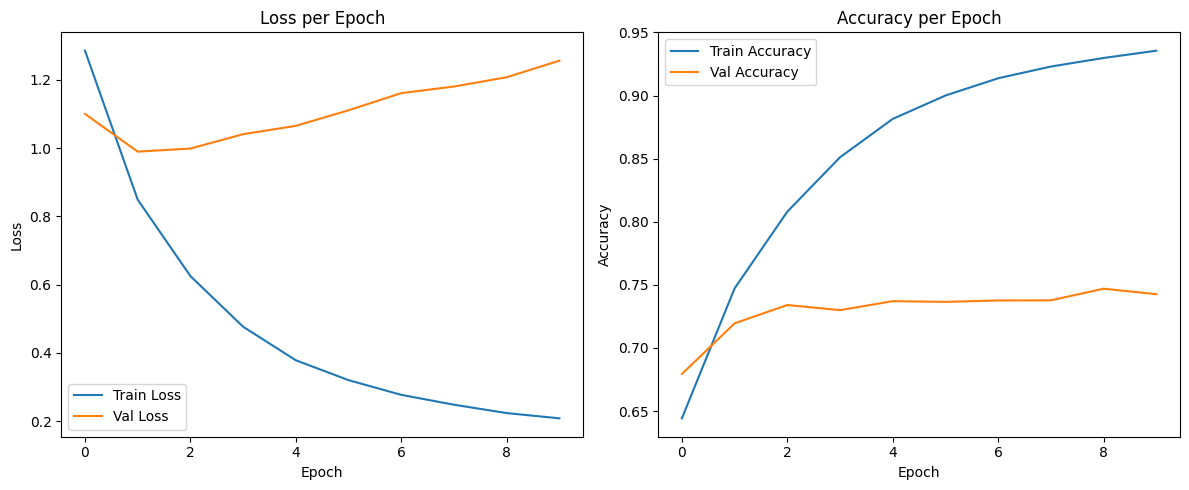

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Val Loss")
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_hist, label="Train Accuracy")
plt.plot(val_acc_hist, label="Val Accuracy")
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


✅ 8. Modell mentése .pt fájlba

In [ ]:
model_path = "/content/vit_b16_finetuned_114.pt"
torch.save(model.state_dict(), model_path)
print(f"💾 Modell mentve: {model_path}")


💾 Modell mentve: /content/vit_b16_finetuned_114.pt


✅ 9. Tesztelés a tanított ViT-B/16 modellen

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, top_k_accuracy_score

model.eval()
all_preds, all_probs, all_labels = [], [], []

start_time = time.perf_counter()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Tesztelés"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

end_time = time.perf_counter()
inference_time = end_time - start_time


Tesztelés: 100%|██████████| 284/284 [00:42<00:00,  6.70it/s]


✅ 10. Metrikák számítása

In [ ]:
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
top5 = top_k_accuracy_score(y_true, y_probs, k=5)

print(f"\n🔍 Vizsgálat eredményei (ViT-B/16 – Full fine-tune @ saját 114 osztály):")
print(f"✅ Top-1 Accuracy:  {accuracy:.4f}")
print(f"✅ Top-5 Accuracy:  {top5:.4f}")
print(f"🎯 Precision:       {precision:.4f}")
print(f"🎯 Recall:          {recall:.4f}")
print(f"🎯 F1-score:        {f1:.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")



🔍 Vizsgálat eredményei (ViT-B/16 – Full fine-tune @ saját 114 osztály):
✅ Top-1 Accuracy:  0.7414
✅ Top-5 Accuracy:  0.9257
🎯 Precision:       0.6935
🎯 Recall:          0.6636
🎯 F1-score:        0.6730
⏱️ Inference time:  42.40 sec


✅ 11. Confusion Matrix, osztály-statisztikák, CSV export

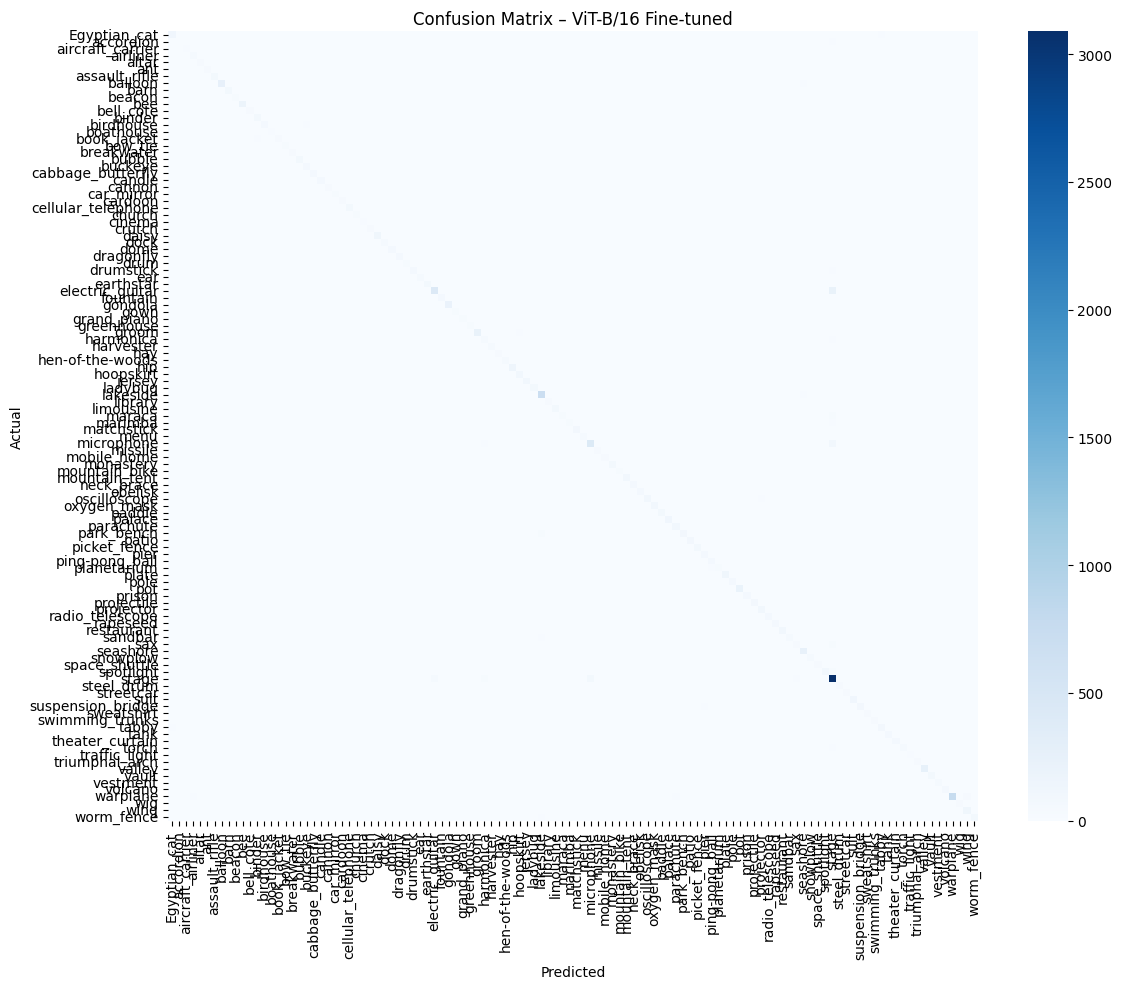


📋 Részletes osztályonkénti metrikák:

                    precision    recall  f1-score   support

      Egyptian_cat       0.82      0.81      0.82       145
         accordion       0.46      0.26      0.33        47
  aircraft_carrier       0.74      0.51      0.61        39
          airliner       0.75      0.72      0.74        80
             altar       0.69      0.73      0.71        59
               ant       0.61      0.46      0.53        95
     assault_rifle       0.73      0.82      0.77        91
           balloon       0.73      0.75      0.74       338
              barn       0.73      0.72      0.73       111
            beacon       0.45      0.55      0.49        62
               bee       0.78      0.83      0.81       212
         bell_cote       0.81      0.55      0.65        77
            binder       0.60      0.77      0.68       105
         birdhouse       0.58      0.57      0.58       116
         boathouse       0.65      0.56      0.60        43


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

class_names = test_dataset.classes

# Confusion matrix
conf_mat = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_mat, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – ViT-B/16 Fine-tuned")
plt.tight_layout()
plt.show()

# Részletes osztályonkénti metrikák
print("\n📋 Részletes osztályonkénti metrikák:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# CSV export
precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_true, y_pred, zero_division=0
)

df_metrics = pd.DataFrame({
    "Class": class_names,
    "Precision": precision_per_class,
    "Recall": recall_per_class,
    "F1-score": f1_per_class,
})
df_metrics.to_csv("/content/vit_b16_finetune_test_metrics.csv", index=False)
print("📁 Mentve: vit_b16_finetune_test_metrics.csv")

# Leggyengébben teljesítő osztályok
print("\n😢 Legrosszabbul teljesítő osztályok:")
print(df_metrics.sort_values("F1-score").head(10))
